## 1. What this notebook computes

A differential equation says how fast a quantity changes. A computer solves it by
taking many small *steps*. This notebook compares three ways of making one step,
the **Euler method**, the **midpoint method** and the **classical fourth-order
Runge-Kutta method (RK4)**, on two equations whose exact solutions we know, so
that every error can be measured exactly. It

- makes one step of each method by hand, with exact fractions;
- derives with sympy the exact *amplification factor* of each method, the number
  by which one step multiplies the solution of $y' = \lambda y$;
- solves the growth of the 3-space scale factor and the deflation of an
  extra-time scale factor of the author's metric along a linear history, and
  shows that Euler's method spoils their exact product $1$;
- measures the error at a fixed end time for step sizes from $1/2$ down to
  $1/262144$, finds the *orders* $1$, $2$ and $4$ of the three methods as the
  slopes of straight lines on log-log plots, and shows where rounding errors stop
  the improvement;
- reads from the Revision record Revision/kohn_sham/results/parameters.json the
  step of the Rust program that solves the book's Kohn-Sham equations with RK4,
  and predicts exactly how large the error of each method is at that step;
- solves the oscillator $d^2x/dt^2 = -x$, draws its phase portrait, and predicts the
  drift of its energy exactly from the amplification factors;
- tests Richardson's rule, which estimates the error of a computation without
  knowing the exact answer.

It draws 8 figures and prints a PASS line for every check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 02a (Euler, midpoint and RK4: the order of a method on a log-log plot) is the
file `Revision/textbook/notebooks/02a_rk4_convergence.ipynb` of the repository
Dirac_claude. It solves two differential equations whose exact solutions are known, the
decay equation (the deflation of an extra-time scale factor along a linear history) and
the oscillator equation, with the Euler method, the midpoint method and the classical
fourth-order Runge-Kutta method (RK4); it derives the exact amplification factor of each
method with sympy, measures how the error at a fixed end time shrinks when the step is
halved, finds the orders 1, 2 and 4 as slopes on log-log plots, shows where rounding
errors stop the improvement, reads the step of the Revision Kohn-Sham solver (900 RK4
steps on an interval of length 3) from its record and predicts the error of each method
at that step from the first missed term of the exponential series, predicts the energy
drift of the oscillator exactly, and tests the Richardson estimate of the error. It needs
a computer with Windows 11, macOS or Linux, an internet connection for the installation,
the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 02a_rk4_convergence.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 02a_rk4_convergence.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
02a_rk4_convergence.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/02a.captions.json`
- `Revision/textbook/figures/02a_1_scale_factors.png`
- `Revision/textbook/figures/02a_2_scale_factor_product.png`
- `Revision/textbook/figures/02a_3_convergence_loglog.png`
- `Revision/textbook/figures/02a_4_error_ratios.png`
- `Revision/textbook/figures/02a_5_rounding_floor.png`
- `Revision/textbook/figures/02a_6_phase_portrait.png`
- `Revision/textbook/figures/02a_7_energy_drift.png`
- `Revision/textbook/figures/02a_8_richardson.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 8 figure files of notebook 02a exist
    ALL 29 CHECKS PASSED (notebook 02a)

and the notebook must show 8 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/02a_rk4_convergence.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 02a_rk4_convergence.ipynb
      python -m nbconvert --execute --inplace 02a_rk4_convergence.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 02a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 02a (Euler, midpoint and RK4: the order of a method on a log-log plot) is the
# file Revision/textbook/notebooks/02a_rk4_convergence.ipynb of the repository
# Dirac_claude. It solves two differential equations whose exact solutions are known, the
# decay equation (the deflation of an extra-time scale factor along a linear history) and
# the oscillator equation, with the Euler method, the midpoint method and the classical
# fourth-order Runge-Kutta method (RK4); it derives the exact amplification factor of
# each method with sympy, measures how the error at a fixed end time shrinks when the
# step is halved, finds the orders 1, 2 and 4 as slopes on log-log plots, shows where
# rounding errors stop the improvement, reads the step of the Revision Kohn-Sham solver
# (900 RK4 steps on an interval of length 3) from its record and predicts the error of
# each method at that step from the first missed term of the exponential series, predicts
# the energy drift of the oscillator exactly, and tests the Richardson estimate of the
# error. It needs a computer with Windows 11, macOS or Linux, an internet connection for
# the installation, the program Git, and Python 3.12 or newer (the notebooks were built
# with Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
# and matplotlib; the other packages run Jupyter, the program that shows and runs
# notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 02a_rk4_convergence.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 02a_rk4_convergence.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 02a_rk4_convergence.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/02a.captions.json
# - Revision/textbook/figures/02a_1_scale_factors.png
# - Revision/textbook/figures/02a_2_scale_factor_product.png
# - Revision/textbook/figures/02a_3_convergence_loglog.png
# - Revision/textbook/figures/02a_4_error_ratios.png
# - Revision/textbook/figures/02a_5_rounding_floor.png
# - Revision/textbook/figures/02a_6_phase_portrait.png
# - Revision/textbook/figures/02a_7_energy_drift.png
# - Revision/textbook/figures/02a_8_richardson.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 8 figure files of notebook 02a exist
#     ALL 29 CHECKS PASSED (notebook 02a)
#
# and the notebook must show 8 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/02a_rk4_convergence.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 02a_rk4_convergence.ipynb
#     python -m nbconvert --execute --inplace 02a_rk4_convergence.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "02a"  # this notebook: chapter 02, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 02a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Derivative**: $y'(t) = dy/dt$ is the rate of change of $y$ at time $t$, the
  slope of the graph of $y$.
- **Ordinary differential equation (ODE)**: an equation $y' = f(t, y)$ that gives
  the rate of change of an unknown function $y(t)$ from $t$ and $y$ itself. Here
  $f$ is a known rule, the *right-hand side*.
- **Initial-value problem**: an ODE together with the starting value $y(0)$.
  Exactly one solution belongs to it (for the smooth $f$ of this notebook).
- **System of ODEs**: several unknown functions changing together, for example
  a position $x$ and a velocity $v$; $y$ is then a list (a *vector*) of numbers.
- **Step size** $h$: the time between two computed points; $N$ steps of size
  $h = T/N$ go from $t = 0$ to $t = T$.
- **Euler, midpoint, RK4**: three rules that compute the value after one step
  from the value before it (the formulas are in section 4).
- **Error**: the computed value minus the exact value (we print its size, the
  *absolute value*).
- **Order** $p$: a method has order $p$ when its error at a fixed end time is
  close to $C h^p$ for small $h$, with a number $C$ that does not depend on $h$.
  Halving $h$ then divides the error by $2^p$.
- **Logarithm, log-log plot**: $\log_{10} x$ is the power to which 10 must be
  raised to give $x$ ($\log_{10} 1000 = 3$). A log-log plot has both axes marked
  in powers of ten, so that $e = C h^p$ becomes the straight line
  $\log e = \log C + p \log h$ whose *slope* is $p$.
- **Rounding error, machine epsilon**: a computer stores about 16 significant
  digits of a number; every operation rounds its result. The spacing of the
  stored numbers near 1 is the machine epsilon $2^{-52} \approx 2.2 \times
  10^{-16}$.
- **Amplification factor** $R(z)$: for the test equation $y' = \lambda y$, one
  step of a method multiplies $y$ by a number $R(z)$ that depends only on
  $z = \lambda h$.
- **Phase portrait**: the curve traced by the point $(x, v)$ (position,
  velocity) as time goes on.
- **Richardson's rule**: an estimate of the error made from two computations with
  the step sizes $h$ and $h/2$.

## 4. The physical and mathematical situation

**The equations.** We solve two initial-value problems.

*Problem A (decay and growth).* $y' = -y$ with $y(0) = 1$. The exact solution is
$y(t) = e^{-t}$, because the derivative of $e^{-t}$ is $-e^{-t}$ and $e^{0} = 1$.
This equation describes the extra times of the author's metric. Lengths along the
three extra times $x_5, x_6, x_7$ carry the scale factor $e^{-a_4}\sin^{1/6}z$
and lengths along 3-space $x_1, x_2, x_3$ the factor $e^{a_4}\sin^{1/6}z$, where
$a_4(x_4)$ depends on the time $x_4$ and $z = 6 H x_8$ on the hidden coordinate.
Along the linear history $a_4 = A H x_4$, which the book uses as a prescribed
background (here $A = 1$ and $H = 1$), at a fixed hidden position the factor
$\sin^{1/6}z$ does not change with $x_4$, so we leave it out and follow
$b = e^{-x_4}$ and $a = e^{x_4}$. The extra-time factor obeys $db/dx_4 = -b$
(problem A with $t = x_4$: the extra times DEFLATE) and the 3-space factor obeys
$da/dx_4 = +a$ (3-space inflates). Their product $a b = e^{x_4} e^{-x_4} = 1$
never changes.

*Problem B (oscillation).* $d^2x/dt^2 = -x$ with $x(0) = 1$, $x'(0) = 0$. With the
velocity $v = x'$ it becomes a system of two first-order equations, $x' = v$ and
$v' = -x$. The exact solution is $x = \cos t$, $v = -\sin t$, and the energy
$E = (x^2 + v^2)/2$ stays exactly $1/2$, because $\cos^2 t + \sin^2 t = 1$.

**The three methods.** Write $y_n$ for the computed value at $t_n = n h$.

- Euler: $y_{n+1} = y_n + h f(t_n, y_n)$. It follows the slope at the start of
  the step for the whole step.
- Midpoint: $k_1 = f(t_n, y_n)$, $k_2 = f(t_n + h/2, y_n + (h/2) k_1)$,
  $y_{n+1} = y_n + h k_2$. It uses the slope at an estimated midpoint.
- RK4: $k_1 = f(t_n, y_n)$, $k_2 = f(t_n + h/2, y_n + (h/2) k_1)$,
  $k_3 = f(t_n + h/2, y_n + (h/2) k_2)$, $k_4 = f(t_n + h, y_n + h k_3)$,
  $y_{n+1} = y_n + (h/6)(k_1 + 2 k_2 + 2 k_3 + k_4)$. It averages four slopes
  with the weights $1 : 2 : 2 : 1$. RK4 is the method with which the Rust
  program of the Revision record solves the Kohn-Sham equations of this book
  (file Revision/kohn_sham/solver/src/shoot.rs); section 12 reads its number of
  steps from the record.

**Why Euler has order 1.** Taylor's theorem gives $y(t + h) = y(t) + h y'(t) +
\frac{1}{2} h^2 y''(s)$ for some $s$ between $t$ and $t + h$. Euler keeps the
first two terms, so one step makes an error of size about $\frac{1}{2} h^2
|y''|$. To reach the end time $T$ we need $N = T/h$ steps; $N$ errors of size
$h^2$ add up to about $N h^2 = T h$, proportional to $h^1$. The midpoint method
has order 2 and RK4 order 4; the amplification factors below show why.

**The amplification factor.** For $y' = \lambda y$ the exact solution after one
step is $e^{\lambda h} y_n = e^{z} y_n$, and $e^{z} = 1 + z + z^2/2 + z^3/6 +
z^4/24 + z^5/120 + \dots$ (the Taylor series of the exponential). We shall find
that Euler keeps the first 2 terms of this series, the midpoint method the first
3 and RK4 the first 5. The first term a method misses decides its order.

## 5. The colours, the three step rules and the solver

The next cell imports the packages, fixes the colours of the plots, and defines
the three step rules exactly as written in section 4. The rules use only
`+`, `-`, `*` and `/`, so the same function works with ordinary numbers, with
exact fractions, with sympy symbols and with numpy vectors. The function `solve`
makes $n$ equal steps from $t = 0$ to $t = T$.

In [2]:
import math  # exp, log10 and other functions of one number
from fractions import Fraction  # exact fractions such as 233/384

import numpy as np  # arrays (vectors) of numbers
import sympy as sp  # exact algebra with symbols

# One colour per method (a set that colour-blind readers can tell apart); every
# method also has its own line style and marker, so the plots read in grey too.
COLORS = {"euler": "#eb6834", "midpoint": "#1baf7a", "rk4": "#2a78d6",
          "exact": "#000000", "guide": "#8a8986"}
MARKERS = {"euler": "s", "midpoint": "^", "rk4": "o"}
LABELS = {"euler": "Euler", "midpoint": "midpoint", "rk4": "RK4"}


def euler_step(f, t, y, h):
    """One Euler step: follow the slope at the start for the whole step."""
    return y + h * f(t, y)


def midpoint_step(f, t, y, h):
    """One midpoint step: use the slope at the estimated middle of the step."""
    k1 = f(t, y)  # the slope at the start
    k2 = f(t + h / 2, y + (h / 2) * k1)  # the slope at the estimated midpoint
    return y + h * k2


def rk4_step(f, t, y, h):
    """One step of the classical fourth-order Runge-Kutta method (RK4)."""
    k1 = f(t, y)  # the slope at the start
    k2 = f(t + h / 2, y + (h / 2) * k1)  # at the midpoint, reached with k1
    k3 = f(t + h / 2, y + (h / 2) * k2)  # at the midpoint again, reached with k2
    k4 = f(t + h, y + h * k3)  # at the end, reached with k3
    return y + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)  # weights 1 : 2 : 2 : 1


METHODS = {"euler": euler_step, "midpoint": midpoint_step, "rk4": rk4_step}


def solve(step, f, y0, t_end, n):
    """n equal steps of the rule step from t = 0 to t = t_end.  Returns the list
    of the n + 1 times and the list of the n + 1 computed values."""
    h = t_end / n  # the step size
    times, values = [0 * h], [y0]
    y = y0
    for i in range(n):
        y = step(f, i * h, y, h)  # t_i = i h (no rounding drift of the time)
        times.append((i + 1) * h)
        values.append(y)
    return times, values


def decay(t, y):
    """Problem A: y' = -y (an extra-time scale factor along the linear history)."""
    return -y


def growth(t, y):
    """y' = +y (the 3-space scale factor along the same history)."""
    return y


say("Three step rules and the solver are defined.")

Three step rules and the solver are defined.


## 6. One step by hand, with exact fractions

We make ONE step of size $h = 1/2$ from $y(0) = 1$ for problem A ($y' = -y$).
With exact fractions the results are: Euler $1 - 1/2 = 1/2$; midpoint
$k_1 = -1$, $k_2 = -(1 - 1/4) = -3/4$, so $1 - 3/8 = 5/8$; RK4
$1 - 1/2 + 1/8 - 1/48 + 1/384 = 233/384$. The exact value is
$e^{-1/2} = 0.6065306597\dots$. The cell lets Python's `Fraction` do the same
arithmetic exactly and checks the three fractions.

In [3]:
h = Fraction(1, 2)  # the step size 1/2 as an exact fraction
one_step = {name: step(decay, 0, Fraction(1), h) for name, step in METHODS.items()}
for name, value in one_step.items():
    say(f"{LABELS[name]:9} after one step: {str(value):8} = {float(value):.10f}")
say(f"exact     e^(-1/2)                 = {math.exp(-0.5):.10f}")
check(one_step["euler"] == Fraction(1, 2), "one Euler step of y' = -y gives 1/2")
check(one_step["midpoint"] == Fraction(5, 8), "one midpoint step gives 5/8")
check(one_step["rk4"] == Fraction(233, 384), "one RK4 step gives 233/384")

Euler     after one step: 1/2      = 0.5000000000
midpoint  after one step: 5/8      = 0.6250000000
RK4       after one step: 233/384  = 0.6067708333
exact     e^(-1/2)                 = 0.6065306597
PASS one Euler step of y' = -y gives 1/2
PASS one midpoint step gives 5/8
PASS one RK4 step gives 233/384


## 7. The exact amplification factors

The next cell applies one step of each method to the test equation $y' = z y$
with the step $h = 1$, starting from $y = 1$, where $z$ is a sympy symbol. The
result is the amplification factor $R(z)$ as a polynomial in $z$. The checks
compare it with the first terms of the Taylor series of $e^{z}$, which sympy
computes with `sp.series`.

The oscillator (problem B) is the same test equation in disguise. Put
$w = x + i v$ with $i^2 = -1$. Then $w' = x' + i v' = v - i x = -i(x + i v) =
-i w$: the test equation with $\lambda = -i$, so one step multiplies $w$ by
$R(-ih)$. The energy is $E = (x^2 + v^2)/2 = |w|^2/2$, so one step multiplies
it by $|R(-ih)|^2 = R(-ih) R(ih)$ (the second factor is the complex conjugate of
the first, because the coefficients of $R$ are real numbers). The cell computes
these three polynomials in $h$ as well; we use them in section 13.

In [4]:
z = sp.symbols("z")  # z = lambda h
hs = sp.symbols("h", positive=True)  # a positive step size, as a symbol


def linear(t, y):
    """The test equation y' = z y."""
    return z * y


one = sp.Integer(1)  # sympy's exact 1 (so that 1/2 stays the exact fraction 1/2)
R = {name: sp.expand(step(linear, 0, one, one)) for name, step in METHODS.items()}
taylor = sp.series(sp.exp(z), z, 0, 6).removeO()  # 1 + z + ... + z^5/120
terms = sp.Poly(taylor, z).all_coeffs()[::-1]  # the coefficients 1, 1, 1/2, ...
for name, keep in (("euler", 2), ("midpoint", 3), ("rk4", 5)):
    partial = sum(terms[k] * z ** k for k in range(keep))  # the first keep terms
    say(f"R_{name}(z) = {sp.expand(R[name])}")
    check(sp.expand(R[name] - partial) == 0,
          f"R_{name}(z) equals the first {keep} terms of the series of e^z")

# The energy factor of one oscillator step, R(i h) R(-i h), as a polynomial in h.
ENERGY_FACTOR = {name: sp.expand(R[name].subs(z, sp.I * hs) *
                                 R[name].subs(z, -sp.I * hs))
                 for name in METHODS}
for name, factor in ENERGY_FACTOR.items():
    say(f"energy factor per step, {LABELS[name]:8}: {factor}")
check(ENERGY_FACTOR["euler"] == 1 + hs ** 2
      and ENERGY_FACTOR["midpoint"] == 1 + hs ** 4 / 4
      and ENERGY_FACTOR["rk4"] == 1 - hs ** 6 / 72 + hs ** 8 / 576,
      "energy factors 1 + h^2, 1 + h^4/4, 1 - h^6/72 + h^8/576")

R_euler(z) = z + 1
PASS R_euler(z) equals the first 2 terms of the series of e^z
R_midpoint(z) = z**2/2 + z + 1
PASS R_midpoint(z) equals the first 3 terms of the series of e^z
R_rk4(z) = z**4/24 + z**3/6 + z**2/2 + z + 1
PASS R_rk4(z) equals the first 5 terms of the series of e^z
energy factor per step, Euler   : h**2 + 1
energy factor per step, midpoint: h**4/4 + 1
energy factor per step, RK4     : h**8/576 - h**6/72 + 1
PASS energy factors 1 + h^2, 1 + h^4/4, 1 - h^6/72 + h^8/576


## 8. The inflating and the deflating scale factor

The next cell solves $da/dt = a$ (the 3-space factor $a = e^{t}$) and
$db/dt = -b$ (the extra-time factor $b = e^{-t}$) from $t = 0$ to $t = 2$ with
the coarse step $h = 0.25$ (8 steps), by Euler and by RK4, and draws them with
the exact curves. Euler multiplies by $1 + h = 1.25$ and by $1 - h = 0.75$ per
step, so after 8 steps it gives $1.25^8$ and $0.75^8$; the checks confirm this.

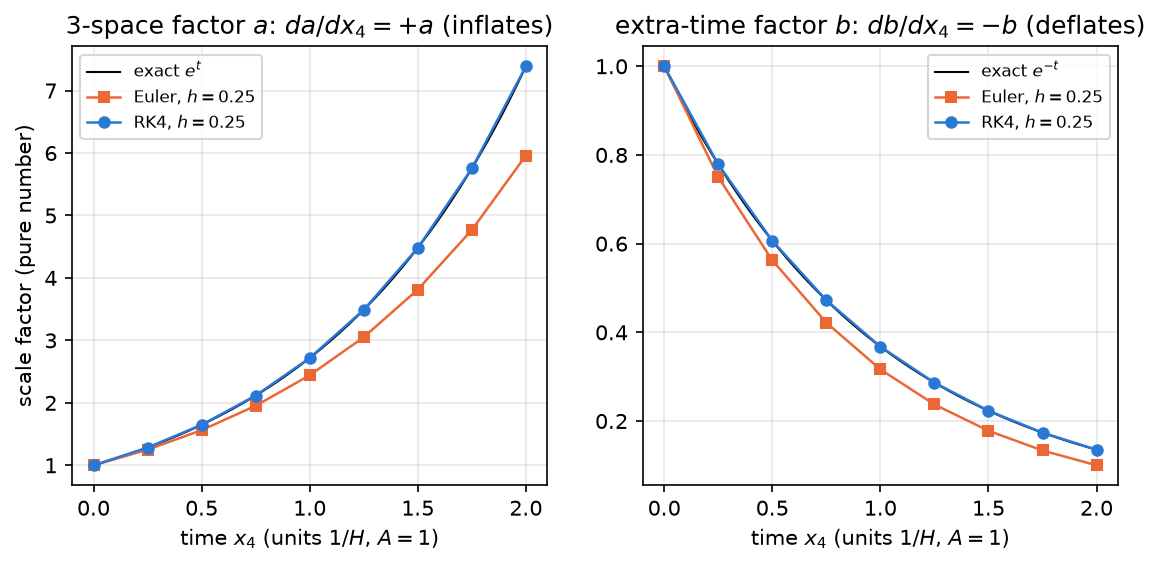

Figure 02a.1 saved as Revision/textbook/figures/02a_1_scale_factors.png
RESULT a(2): exact, Euler, RK4 = 7.389056, 5.960464, 7.388665
RESULT b(2): exact, Euler, RK4 = 0.135335, 0.100113, 0.135346
PASS Euler gives exactly 1.25^8 and 0.75^8 after 8 steps
PASS RK4 with h = 0.25 is within 0.1 percent of e^2 and e^(-2)


In [5]:
H_COARSE, STEPS = 0.25, 8  # step size and number of steps: t from 0 to 2
curves = {}
for name in ("euler", "rk4"):
    t_list, a_list = solve(METHODS[name], growth, 1.0, 2.0, STEPS)
    _, b_list = solve(METHODS[name], decay, 1.0, 2.0, STEPS)
    curves[name] = (np.array(t_list), np.array(a_list), np.array(b_list))
t_fine = np.linspace(0.0, 2.0, 201)  # many points for the exact curves

fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
left.plot(t_fine, np.exp(t_fine), color=COLORS["exact"], lw=1.0,
          label="exact $e^{t}$")
right.plot(t_fine, np.exp(-t_fine), color=COLORS["exact"], lw=1.0,
           label="exact $e^{-t}$")
for name in ("euler", "rk4"):
    t_n, a_n, b_n = curves[name]
    style = dict(color=COLORS[name], marker=MARKERS[name], ms=5, lw=1.2)
    left.plot(t_n, a_n, **style, label=f"{LABELS[name]}, $h = 0.25$")
    right.plot(t_n, b_n, **style, label=f"{LABELS[name]}, $h = 0.25$")
left.set_title("3-space factor $a$: $da/dx_4 = +a$ (inflates)")
right.set_title("extra-time factor $b$: $db/dx_4 = -b$ (deflates)")
for ax in (left, right):
    ax.set_xlabel("time $x_4$ (units $1/H$, $A = 1$)")
    ax.legend(fontsize=8)
left.set_ylabel("scale factor (pure number)")
save_figure(fig, "scale_factors",
            "Left: the 3-space scale factor $a = e^{x_4}$, which obeys "
            "$da/dx_4 = a$; right: the extra-time scale factor $b = e^{-x_4}$, "
            "which obeys $db/dx_4 = -b$, along the linear history $a_4 = A H x_4$ "
            "with $A = H = 1$ at a fixed hidden position. Horizontal axis the time "
            "$x_4$ in units of $1/H$, vertical axis the scale factor (a pure "
            "number). Black: the exact curves; squares: Euler with the step "
            "$h = 0.25$; circles: RK4 with the same step. Euler falls behind the "
            "growing curve and decays too fast; RK4 lies on both exact curves.")
a_euler, b_euler = curves["euler"][1][-1], curves["euler"][2][-1]
a_rk4, b_rk4 = curves["rk4"][1][-1], curves["rk4"][2][-1]
report("a(2): exact, Euler, RK4", f"{math.exp(2):.6f}, {a_euler:.6f}, {a_rk4:.6f}")
report("b(2): exact, Euler, RK4", f"{math.exp(-2):.6f}, {b_euler:.6f}, {b_rk4:.6f}")
check(abs(a_euler - 1.25 ** 8) < 1e-12 and abs(b_euler - 0.75 ** 8) < 1e-15,
      "Euler gives exactly 1.25^8 and 0.75^8 after 8 steps")
check(abs(a_rk4 / math.exp(2) - 1) < 1e-3 and abs(b_rk4 / math.exp(-2) - 1) < 1e-3,
      "RK4 with h = 0.25 is within 0.1 percent of e^2 and e^(-2)")

The exact product $a b = e^{t} e^{-t}$ is $1$ at every time: the inflation of a
3-space direction is compensated exactly by the deflation of an extra-time
direction. A numerical method multiplies $a$ by $R(h)$ and $b$ by $R(-h)$ per
step, so it multiplies the product by $R(h) R(-h)$. For Euler that is
$(1 + h)(1 - h) = 1 - h^2$: the product shrinks by the factor $1 - h^2$ at every
step, however long we compute. For RK4 the cell lets sympy multiply out
$R(h) R(-h)$: the terms with $h$, $h^2$, $h^3$, $h^4$ and $h^5$ all cancel and
$1 + h^6/72 + h^8/576$ remains, which is much closer to $1$. The left panel of
the figure shows the product itself, the right panel its distance from $1$ on a
logarithmic scale, where both methods can be seen.

factor of a b per step, Euler: 1 - h**2
factor of a b per step, RK4  : h**8/576 + h**6/72 + 1
PASS R(h) R(-h) is 1 - h^2 (Euler) and 1 + h^6/72 + h^8/576 (RK4)


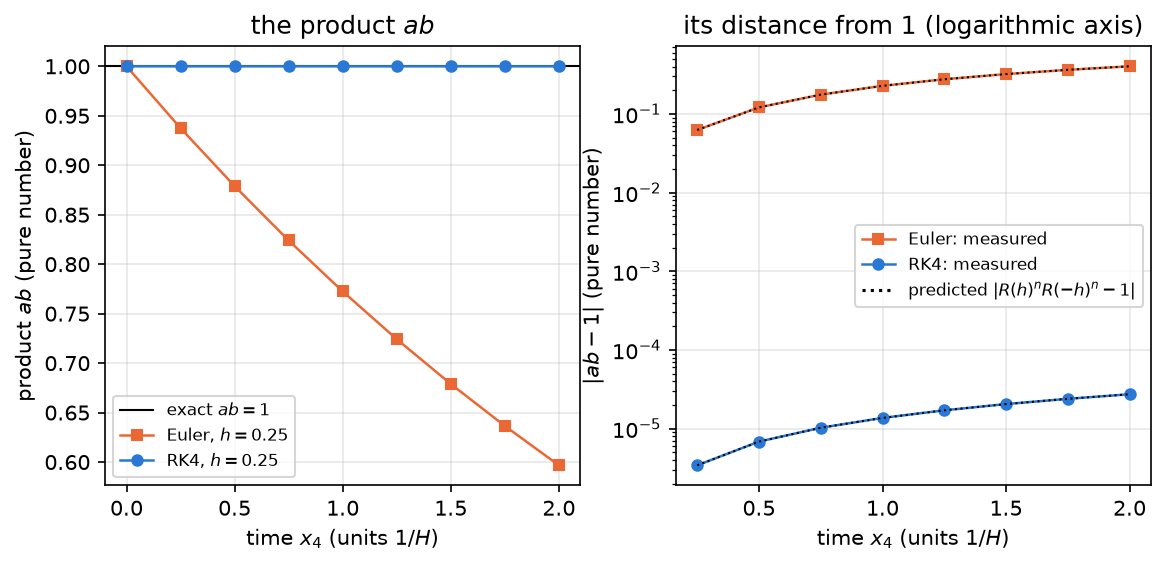

Figure 02a.2 saved as Revision/textbook/figures/02a_2_scale_factor_product.png
PASS Euler multiplies the product a b by 1 - h^2 per step
PASS RK4 multiplies a b by 1 + h^6/72 + h^8/576 per step (within 3e-5 of 1)


In [6]:
PRODUCT_FACTOR = {name: sp.expand(R[name].subs(z, hs) * R[name].subs(z, -hs))
                  for name in ("euler", "rk4")}
for name, factor in PRODUCT_FACTOR.items():
    say(f"factor of a b per step, {LABELS[name]:5}: {factor}")
check(PRODUCT_FACTOR["euler"] == 1 - hs ** 2
      and PRODUCT_FACTOR["rk4"] == 1 + hs ** 6 / 72 + hs ** 8 / 576,
      "R(h) R(-h) is 1 - h^2 (Euler) and 1 + h^6/72 + h^8/576 (RK4)")

fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
left.axhline(1.0, color=COLORS["exact"], lw=1.0, label="exact $a b = 1$")
products = {}
for name in ("euler", "rk4"):
    t_n, a_n, b_n = curves[name]
    products[name] = a_n * b_n  # the computed product at every step
    factor = float(PRODUCT_FACTOR[name].subs(hs, sp.Rational(1, 4)))  # h = 1/4
    style = dict(color=COLORS[name], marker=MARKERS[name], ms=5, lw=1.2)
    left.plot(t_n, products[name], **style, label=f"{LABELS[name]}, $h = 0.25$")
    right.semilogy(t_n[1:], np.abs(products[name][1:] - 1.0), **style,
                   label=f"{LABELS[name]}: measured")
    predicted = np.abs(factor ** np.arange(1, STEPS + 1) - 1.0)
    right.semilogy(t_n[1:], predicted, ":", color=COLORS["exact"], lw=1.0)
right.plot([], [], ":", color=COLORS["exact"], label="predicted $|R(h)^n R(-h)^n - 1|$")
left.set_ylabel("product $a b$ (pure number)")
right.set_ylabel("$|a b - 1|$ (pure number)")
left.set_title("the product $a b$")
right.set_title("its distance from 1 (logarithmic axis)")
for ax in (left, right):
    ax.set_xlabel("time $x_4$ (units $1/H$)")
    ax.legend(fontsize=8)
save_figure(fig, "scale_factor_product",
            "Left: the product $a b$ of the 3-space factor and the extra-time "
            "factor of the previous figure, computed with the step $h = 0.25$; "
            "right: its distance $|a b - 1|$ from the exact value on a logarithmic "
            "axis. Horizontal axes the time $x_4$ in units of $1/H$; the product is "
            "a pure number. Exactly $a b = e^{x_4} e^{-x_4} = 1$ (black line). Euler "
            "(squares) multiplies the product by $1 - h^2 = 0.9375$ at every step "
            "and ends at $0.9375^8 = 0.597$; RK4 (circles) multiplies it by "
            "$1 + h^6/72 + h^8/576$ and ends within $3 \\times 10^{-5}$ of 1. The "
            "dotted lines are these predictions; the measured points lie on them.")
check(abs(products["euler"][-1] - (1 - H_COARSE ** 2) ** 8) < 1e-14,
      "Euler multiplies the product a b by 1 - h^2 per step")
rk4_factor = 1 + H_COARSE ** 6 / 72 + H_COARSE ** 8 / 576
check(abs(products["rk4"][-1] - rk4_factor ** 8) < 1e-14
      and abs(products["rk4"][-1] - 1) < 3e-5,
      "RK4 multiplies a b by 1 + h^6/72 + h^8/576 per step (within 3e-5 of 1)")

## 9. The convergence study: errors on a log-log plot

Now the main experiment. For each method we solve problem A from $t = 0$ to
$t = 1$ with $N = 2, 4, 8, \dots, 4096$ steps ($h = 1/N$) and record the error
$|y_N - e^{-1}|$ at the end time. The cell prints the table and fits a straight
line $\log e = \log C + p \log h$ through the points where the error is still
much larger than the rounding errors, with numpy's `polyfit` (a least-squares
fit: the line with the smallest sum of squared vertical distances). The slope
$p$ is the measured order. The table also reproduces the classic numbers of
Euler's method, $(1 - h)^N$ = 0.250000, 0.316406, 0.343609, 0.356074 for
$h = 1/2, 1/4, 1/8, 1/16$.

In [7]:
EXACT_A = math.exp(-1.0)  # the exact value y(1) = e^(-1)
N_LIST = [2 ** k for k in range(1, 13)]  # 2, 4, ..., 4096 steps
ends = {name: [solve(step, decay, 1.0, 1.0, n)[1][-1] for n in N_LIST]
        for name, step in METHODS.items()}
errors = {name: np.abs(np.array(values) - EXACT_A) for name, values in ends.items()}
say("     N        h     Euler y_N   error Euler  error midpoint     error RK4")
for i, n in enumerate(N_LIST):
    y_euler = ends["euler"][i]  # the Euler value y_N
    e_euler, e_mid, e_rk4 = (errors[name][i] for name in METHODS)  # three errors
    say(f"{n:6d} {1 / n:8.6f}  {y_euler:12.6f}  {e_euler:11.3e}  {e_mid:14.3e}  "
        f"{e_rk4:12.3e}")

h_array = 1.0 / np.array(N_LIST, dtype=float)
FIT = {"euler": slice(5, 12), "midpoint": slice(5, 12), "rk4": slice(1, 8)}
slopes = {}
for name, part in FIT.items():
    # polyfit(x, y, 1) returns (slope, intercept) of the best straight line.
    slope, _ = np.polyfit(np.log10(h_array[part]), np.log10(errors[name][part]), 1)
    slopes[name] = slope
    report(f"measured order of {LABELS[name]} (slope)", f"{slope:.4f}")
check([round(v, 6) for v in ends["euler"][:4]]
      == [0.25, 0.316406, 0.343609, 0.356074],
      "Euler values (1 - h)^N for h = 1/2, 1/4, 1/8, 1/16")
check(abs(slopes["euler"] - 1) < 0.02 and abs(slopes["midpoint"] - 2) < 0.02
      and abs(slopes["rk4"] - 4) < 0.1,
      "the measured orders are 1, 2 and 4")

     N        h     Euler y_N   error Euler  error midpoint     error RK4
     2 0.500000      0.250000    1.179e-01       2.275e-02     2.914e-04
     4 0.250000      0.316406    5.147e-02       4.650e-03     1.476e-05
     8 0.125000      0.343609    2.427e-02       1.054e-03     8.308e-07
    16 0.062500      0.356074    1.181e-02       2.511e-04     4.928e-08
    32 0.031250      0.362055    5.824e-03       6.130e-05     3.001e-09
    64 0.015625      0.364987    2.893e-03       1.515e-05     1.851e-10
   128 0.007812      0.366438    1.442e-03       3.764e-06     1.149e-11
   256 0.003906      0.367160    7.197e-04       9.383e-07     7.159e-13
   512 0.001953      0.367520    3.595e-04       2.342e-07     4.452e-14
  1024 0.000977      0.367700    1.797e-04       5.852e-08     2.054e-15
  2048 0.000488      0.367790    8.983e-05       1.462e-08     1.665e-16
  4096 0.000244      0.367835    4.491e-05       3.655e-09     1.110e-16
RESULT measured order of Euler (slope) = 1.0014
RE

The next cell draws the table as a log-log plot. The grey dashed guide lines have
the slopes 1, 2 and 4 exactly; each passes through the last fitted point of its
method. The measured points must lie on lines parallel to them.

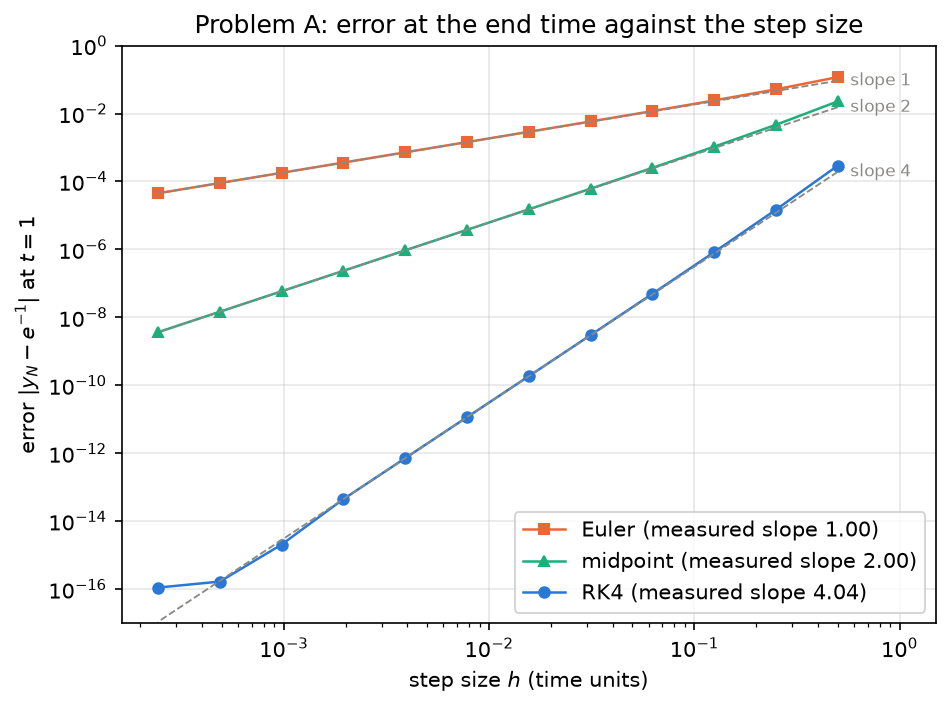

Figure 02a.3 saved as Revision/textbook/figures/02a_3_convergence_loglog.png
PASS at N = 256: RK4 error < 1e-11 < midpoint error < Euler error


In [8]:
fig, ax = plt.subplots(figsize=(7.0, 5.0))
for name in METHODS:
    ax.loglog(h_array, errors[name], color=COLORS[name], marker=MARKERS[name],
              ms=5, lw=1.2, label=f"{LABELS[name]} (measured slope "
              f"{slopes[name]:.2f})")
    order = {"euler": 1, "midpoint": 2, "rk4": 4}[name]
    anchor = FIT[name].stop - 1  # the last fitted point
    guide = errors[name][anchor] * (h_array / h_array[anchor]) ** order
    ax.loglog(h_array, guide, "--", color=COLORS["guide"], lw=0.9)
    ax.text(h_array[0] * 1.15, guide[0], f"slope {order}", fontsize=8,
            color=COLORS["guide"], va="center")
ax.set_xlim(h_array[-1] / 1.5, h_array[0] * 3.0)
ax.set_ylim(1e-17, 1.0)
ax.set_xlabel("step size $h$ (time units)")
ax.set_ylabel("error $|y_N - e^{-1}|$ at $t = 1$")
ax.set_title("Problem A: error at the end time against the step size")
ax.legend(loc="lower right")
save_figure(fig, "convergence_loglog",
            "The error at the end time $t = 1$ of problem A, $y' = -y$, for the "
            "Euler method (squares), the midpoint method (triangles) and RK4 "
            "(circles), against the step size $h$ from $1/2$ down to $1/4096$, on "
            "logarithmic axes (each tick a power of ten; time in arbitrary units, "
            "the error a pure number). The dashed grey lines have the slopes 1, 2 "
            "and 4. The points lie on straight lines parallel to them: the error is "
            "$C h^p$ with the orders $p = 1, 2, 4$. The RK4 points bend away at the "
            "bottom left, where rounding errors take over.")
check(errors["rk4"][7] < 1e-11 < errors["midpoint"][7] < errors["euler"][7],
      "at N = 256: RK4 error < 1e-11 < midpoint error < Euler error")

## 10. What halving the step does

If the error is $C h^p$, then halving $h$ divides it by exactly $2^p$: by 2 for
Euler, 4 for the midpoint method and 16 for RK4. The next cell computes the
ratios $e(h)/e(h/2)$ for successive rows of the table, draws them, and checks the
ratios where the error is not yet limited by rounding.

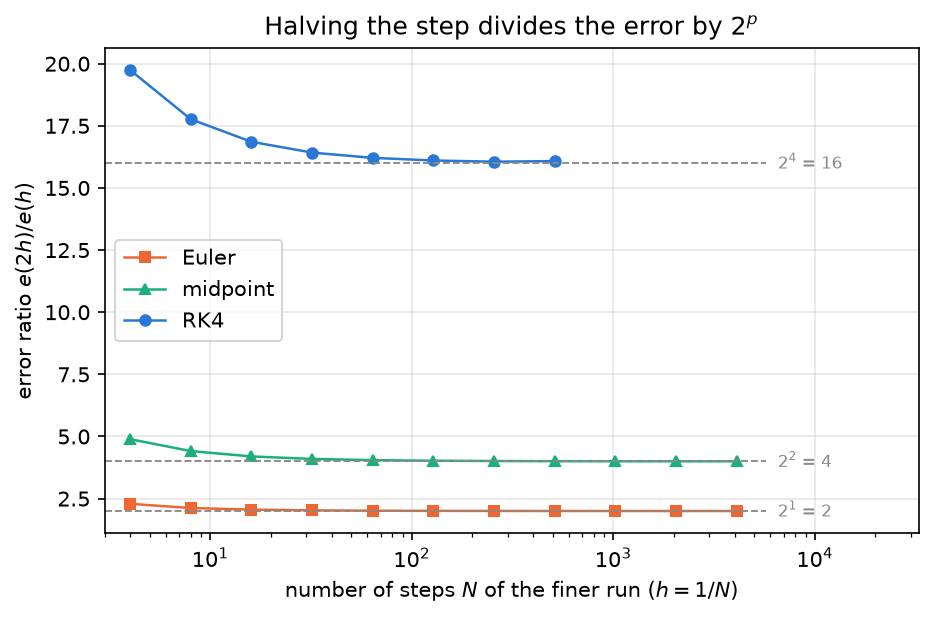

Figure 02a.4 saved as Revision/textbook/figures/02a_4_error_ratios.png
RESULT ratio Euler at N = 4096 = 2.00020
RESULT ratio midpoint at N = 4096 = 4.00073
RESULT ratio RK4 at N = 128 = 16.1047
PASS halving h divides the errors by 2, 4 and 16


In [9]:
ratios = {name: errors[name][:-1] / errors[name][1:] for name in METHODS}
fig, ax = plt.subplots()
for name in METHODS:
    shown = slice(0, 8) if name == "rk4" else slice(0, 11)  # RK4: before rounding
    ax.semilogx(N_LIST[1:][shown], ratios[name][shown], color=COLORS[name],
                marker=MARKERS[name], ms=5, lw=1.2, label=LABELS[name])
for target in (2, 4, 16):
    # a dashed line from N = 3 to just beyond the data, its label to the right
    ax.hlines(target, 3.0, N_LIST[-1] * 1.4, ls="--", color=COLORS["guide"], lw=0.9)
    ax.text(N_LIST[-1] * 1.6, target, f"$2^{{{int(math.log2(target))}}}$ = "
            f"{target}", va="center", ha="left", fontsize=8, color=COLORS["guide"])
ax.set_xlim(3.0, N_LIST[-1] * 8.0)  # room on the right for the labels
ax.set_xlabel("number of steps $N$ of the finer run ($h = 1/N$)")
ax.set_ylabel("error ratio $e(2h)/e(h)$")
ax.set_title("Halving the step divides the error by $2^p$")
ax.legend(loc="center left")
save_figure(fig, "error_ratios",
            "The factor by which the error of problem A at $t = 1$ shrinks when the "
            "step is halved, against the number of steps $N$ of the finer run "
            "(logarithmic horizontal axis; the ratio is a pure number). The ratios "
            "approach 2 for Euler (squares), 4 for the midpoint method "
            "(triangles) and 16 for RK4 (circles), the values $2^p$ for the "
            "orders $p = 1, 2, 4$ (dashed grey lines). RK4 is drawn only up to "
            "$N = 512$; beyond, its error is rounding noise.")
ratio_euler = ratios["euler"][-1]  # the last ratio: N = 2048 -> 4096
ratio_midpoint = ratios["midpoint"][-1]
ratio_rk4 = ratios["rk4"][5]  # N = 64 -> 128, before rounding matters
report("ratio Euler at N = 4096", f"{ratio_euler:.5f}")
report("ratio midpoint at N = 4096", f"{ratio_midpoint:.5f}")
report("ratio RK4 at N = 128", f"{ratio_rk4:.4f}")
check(abs(ratio_euler - 2) < 0.001 and abs(ratio_midpoint - 4) < 0.001
      and abs(ratio_rk4 - 16) < 0.2,
      "halving h divides the errors by 2, 4 and 16")

## 11. Where rounding takes over

A smaller step is not always better. Every arithmetic operation rounds its result
to about 16 significant digits, and with $N$ steps about $N$ such rounding errors
add up. If they all had their largest size and the same sign, their total would
be about $N \epsilon$ times the size of the solution: a pessimistic bound. In
practice they have both signs and partly cancel, so the total stays far below
this bound, but it still grows with the number of steps $N = 1/h$, while the
truncation error of RK4 falls like $h^4$. The next cell runs RK4 for problem A
with up to $2^{18} = 262144$ steps (this takes about a second) and draws both
effects: the error falls along the slope-4 line until it reaches about
$10^{-16}$, then rises again, slowly and far below the bound.

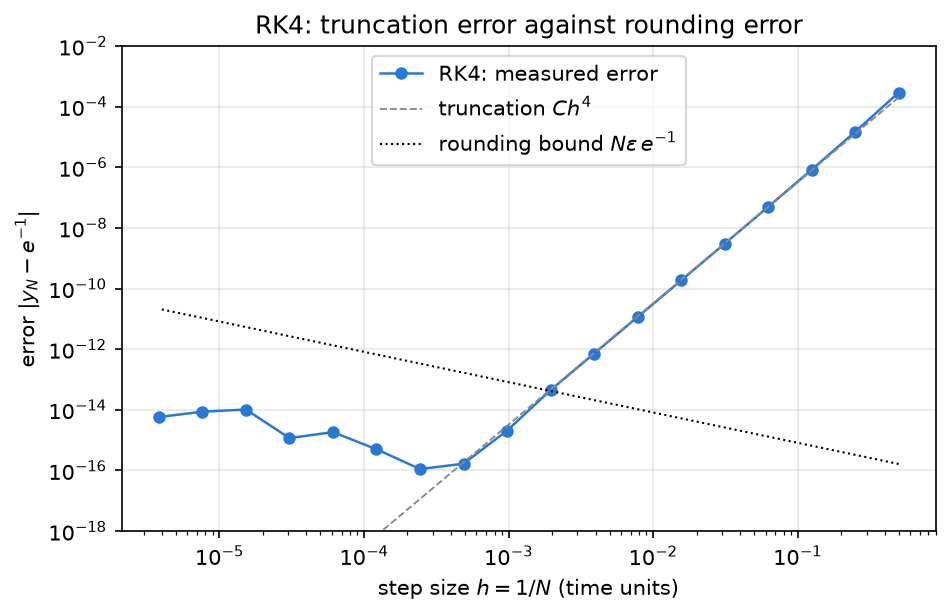

Figure 02a.5 saved as Revision/textbook/figures/02a_5_rounding_floor.png
RESULT smallest RK4 error = 1.110e-16 at N = 4096
RESULT RK4 error at N = 262144 = 5.773e-15
RESULT bound N eps e^-1 / measured error past the minimum (smallest, largest) = 524, 3709
PASS the smallest RK4 error is below 1e-15, reached at N between 256 and 16384
PASS with 262144 steps rounding has made the error grow again
PASS past the minimum the error stays over 100 times below the bound N eps e^-1


In [10]:
N_LONG = [2 ** k for k in range(1, 19)]  # 2 ... 262144 steps
rk4_long = np.array([abs(solve(rk4_step, decay, 1.0, 1.0, n)[1][-1] - EXACT_A)
                     for n in N_LONG])
h_long = 1.0 / np.array(N_LONG, dtype=float)
best = int(np.argmin(rk4_long))  # the position of the smallest error
EPS = 2.0 ** -52  # the machine epsilon
fig, ax = plt.subplots()
shown = rk4_long > 0  # an error of exactly 0 cannot be drawn on a log axis
ax.loglog(h_long[shown], rk4_long[shown], color=COLORS["rk4"], marker="o", ms=5,
          lw=1.2, label="RK4: measured error")
ax.loglog(h_long, errors["rk4"][3] * (h_long / h_array[3]) ** 4, "--",
          color=COLORS["guide"], lw=0.9, label="truncation $C h^4$")
ax.loglog(h_long, EPS * EXACT_A / h_long, ":", color=COLORS["exact"], lw=1.0,
          label="rounding bound $N \\epsilon\\, e^{-1}$")
ax.set_ylim(1e-18, 1e-2)
ax.set_xlabel("step size $h = 1/N$ (time units)")
ax.set_ylabel("error $|y_N - e^{-1}|$")
ax.set_title("RK4: truncation error against rounding error")
ax.legend(loc="upper center")
save_figure(fig, "rounding_floor",
            "The error of RK4 for problem A at $t = 1$ against the step size $h$ "
            "from $1/2$ to $1/262144$, on logarithmic axes (time in arbitrary "
            "units, the error a pure number). Circles: measured. Dashed grey: the "
            "truncation error $C h^4$. Dotted black: the pessimistic bound "
            "$N \\epsilon\\, e^{-1}$, reached only if all $N$ rounding errors of "
            "relative size $\\epsilon = 2^{-52}$ had their largest size and the "
            "same sign. Coming from the right, the error falls with slope 4 down "
            "to about $10^{-16}$; for smaller steps it grows again, but slowly "
            "and hundreds to thousands of times below the dotted bound, because "
            "the rounding errors partly cancel.")
report("smallest RK4 error", f"{rk4_long[best]:.3e} at N = {N_LONG[best]}")
report("RK4 error at N = 262144", f"{rk4_long[-1]:.3e}")
bound = EPS * EXACT_A * np.array(N_LONG, dtype=float)  # the dotted line
below = bound[best + 1:] / rk4_long[best + 1:]  # past the minimum: bound / error
report("bound N eps e^-1 / measured error past the minimum (smallest, largest)",
       f"{below.min():.0f}, {below.max():.0f}")
check(rk4_long[best] < 1e-15 and 256 <= N_LONG[best] <= 16384,
      "the smallest RK4 error is below 1e-15, reached at N between 256 and 16384")
check(rk4_long[-1] > 10 * max(rk4_long[best], EPS * EXACT_A)
      and rk4_long[-1] < 1e-11,
      "with 262144 steps rounding has made the error grow again")
check(np.all(below > 100),
      "past the minimum the error stays over 100 times below the bound N eps e^-1")

## 12. The step of the Revision Kohn-Sham solver, and the first missed term

The Rust program of the Revision record that solves the Kohn-Sham equations of
this book makes $G$ equal RK4 steps over an interval of length $L$ of the hidden
coordinate. The next cell reads $G$ and $L$ from the record
Revision/kohn_sham/results/parameters.json, together with the constants $A$ and
$H$ of the linear history $a_4 = A H x_4$ that section 8 used, and computes the
solver's step $h = L/G$. Here we use only this step, not the solver's equations.

How large is the error of a method of order $p$ at this step? For problem A we
can say it exactly to leading order. One step multiplies $y$ by $R(-h)$ instead
of the exact factor $e^{-h} = 1 - h + h^2/2 - h^3/6 + \dots$ Section 7 showed
that $R$ keeps the terms of this series up to the power $h^p$, so $R(-h)$
differs from $e^{-h}$ first by the missed term with the power $h^{p + 1}$:

$$R(-h) = e^{-h} - \frac{(-h)^{p+1}}{(p+1)!} + \dots$$

(the dots stand for terms with higher powers of $h$). Taking out the factor
$e^{-h}$ gives $R(-h) = e^{-h}(1 - q)$ with $q = e^{h}(-h)^{p+1}/(p+1)! + \dots
\approx (-h)^{p+1}/(p+1)!$, because $e^{h} = 1 + h + \dots$ changes only the
higher terms. After $N = 1/h$ steps (up to $t = 1$) the computed value is
$y_N = R(-h)^N = e^{-N h}(1 - q)^N = e^{-1}(1 - q)^N$. For a small $q$,
$(1 - q)^N \approx 1 - N q$ (the first two terms of the binomial theorem), and
$N q = (-1)^{p+1} h^{p}/(p+1)!$ (one factor $h$ cancels against $N = 1/h$). So

$$y_N - e^{-1} \approx e^{-1}\, \frac{(-1)^{p}\, h^{p}}{(p+1)!} .$$

Euler ($p = 1$) ends too LOW by $e^{-1} h/2$; the midpoint method ($p = 2$)
too HIGH by $e^{-1} h^2/6$; RK4 ($p = 4$) too high by $e^{-1} h^4/120$. The
cell solves problem A with the solver's step and compares the measured signed
errors with these predictions.

In [11]:
PARAMETERS = "Revision/kohn_sham/results/parameters.json"
parameters = json.loads(repository_file(PARAMETERS).read_text(encoding="utf-8"))
G_KS = parameters["numerics"]["rk4Steps"]  # the solver's number of RK4 steps
L_KS = parameters["physics"]["L_tipCutoff"]  # the length of its interval in y
A_KS = parameters["physics"]["historyA"]  # the constant A of a4 = A H x4
H_KS = parameters["physics"]["H"]  # the author's constant H
h_ks = L_KS / G_KS  # the solver's step
report("solver: RK4 steps G, interval length L, step h = L/G",
       f"{G_KS}, {L_KS}, {h_ks:.10f}")
report("linear history a4 = A H x4 of the record: A, H", f"{A_KS}, {H_KS}")
check(G_KS == 900 and L_KS == 3.0 and A_KS == 1.0 and H_KS == 1.0,
      "the solver makes 900 RK4 steps on L = 3 (h = 1/300); the history has A = H = 1",
      record=f"{PARAMETERS}, keys rk4Steps, L_tipCutoff, historyA and H")

N_KS = round(1.0 / h_ks)  # 300 steps of h = 1/300 reach t = 1
ORDER = {"euler": 1, "midpoint": 2, "rk4": 4}  # the orders measured in section 9
agreement = []
for name, step in METHODS.items():
    p = ORDER[name]
    measured = solve(step, decay, 1.0, 1.0, N_KS)[1][-1] - EXACT_A  # signed error
    predicted = EXACT_A * (-1) ** p * h_ks ** p / math.factorial(p + 1)
    agreement.append(measured / predicted)
    say(f"{LABELS[name]:9} with h = 1/{N_KS}: error {measured:+.4e}, predicted "
        f"{predicted:+.4e}, ratio {measured / predicted:.5f}")
check(all(abs(ratio - 1) < 0.01 for ratio in agreement),
      "at the solver's step the errors are e^(-1) (-1)^p h^p/(p+1)! within 1 %")

RESULT solver: RK4 steps G, interval length L, step h = L/G = 900, 3.0, 0.0033333333
RESULT linear history a4 = A H x4 of the record: A, H = 1.0, 1.0
PASS the solver makes 900 RK4 steps on L = 3 (h = 1/300); the history has A = H = 1
     reproduces Revision/kohn_sham/results/parameters.json, keys rk4Steps, L_tipCutoff,
    historyA and H
Euler     with h = 1/300: error -6.1399e-04, predicted -6.1313e-04, ratio 1.00139
midpoint  with h = 1/300: error +6.8296e-07, predicted +6.8126e-07, ratio 1.00250
RK4       with h = 1/300: error +3.7920e-13, predicted +3.7848e-13, ratio 1.00190
PASS at the solver's step the errors are e^(-1) (-1)^p h^p/(p+1)! within 1 %


## 13. The oscillator: phase portrait and energy

Problem B as a system: the state is the vector $Y = (x, v)$ and the right-hand
side is $f(t, Y) = (v, -x)$. The exact solution goes round the circle
$x^2 + v^2 = 1$ in the $(x, v)$ plane, once every $2\pi$ time units. The next cell
solves it with the step $h = 0.2$ up to $t = 10$ (50 steps) with each method and
draws the three phase portraits. Section 7 predicts what happens to the energy
$E = (x^2 + v^2)/2$: each step multiplies it by $1 + h^2 = 1.04$ (Euler: the
point spirals outwards), by $1 + h^4/4 = 1.0004$ (midpoint) and by
$1 - h^6/72 + h^8/576 = 0.99999911$ (RK4).

The radius $\sqrt{x^2 + v^2} = \sqrt{2E}$ of the midpoint method grows only to
$\sqrt{1.0004^{50}} = 1.010$ in 50 steps, too little to be seen on the whole
circle. The right panel therefore zooms in on the last three points, at
$t = 9.6$, $9.8$ and $10$, where crosses mark the exact solution at the same
times. There a second error shows: each step
turns the point by a slightly wrong angle. With $w = x + i v$, one step
multiplies $w$ by $R(-ih)$, whose angle is $-\arg R(ih)$ (the angle of a complex
number is called its *argument*, $\arg$), while the exact factor $e^{-ih}$ turns
by $-h$. So after 50 steps the computed point runs ahead of the exact one,
clockwise, by the angle $50\,(\arg R(ih) - h)$; a negative value means that it
lags behind. The cell checks this prediction for the three methods.

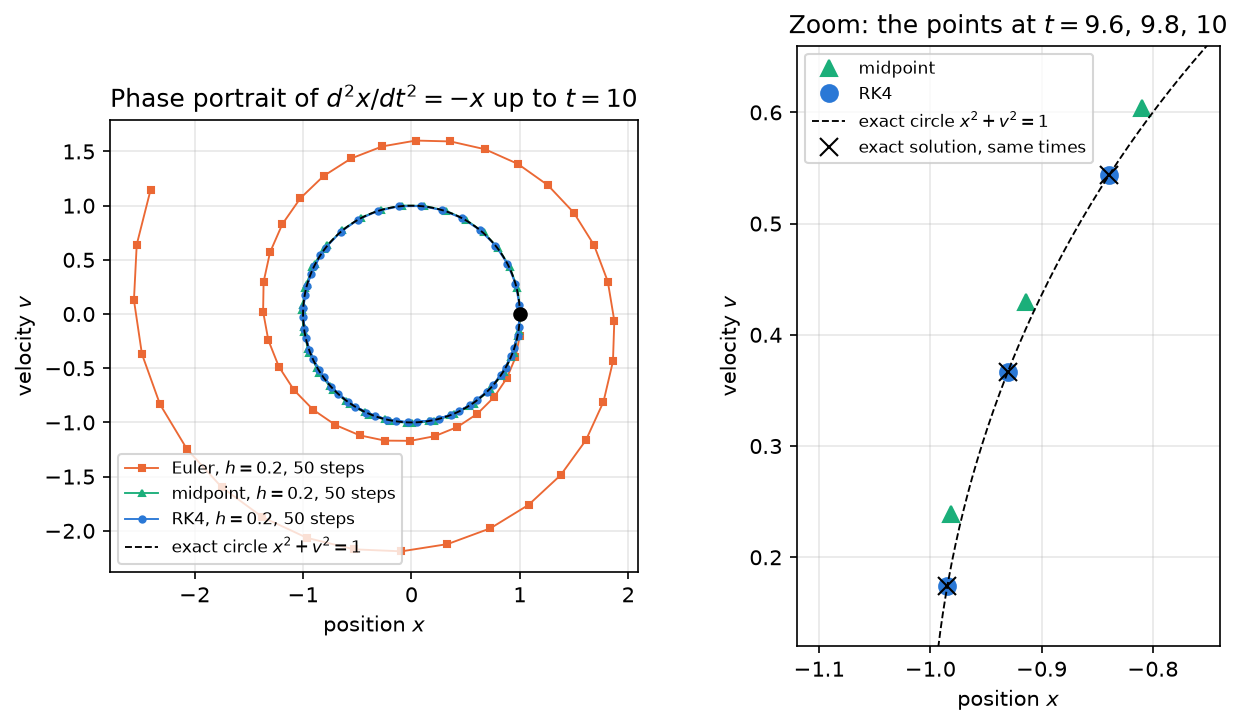

Figure 02a.6 saved as Revision/textbook/figures/02a_6_phase_portrait.png
RESULT energy after 50 steps, Euler = 3.5533416731
PASS Euler: E_n = E_0 times the exact factor to the power n
RESULT energy after 50 steps, midpoint = 0.5100986302
PASS midpoint: E_n = E_0 times the exact factor to the power n
RESULT energy after 50 steps, RK4 = 0.4999778894
PASS RK4: E_n = E_0 times the exact factor to the power n
RESULT t = 10, Euler: radius, angle ahead of the exact point = 2.6658, -1.302e-01 rad
RESULT t = 10, midpoint: radius, angle ahead of the exact point = 1.0100, +6.586e-02 rad
RESULT t = 10, RK4: radius, angle ahead of the exact point = 1.0000, -1.314e-04 rad
PASS at t = 10 each point is ahead of the exact one by 50 (arg R(ih) - h)


In [12]:
def oscillator(t, Y):
    """Problem B: x' = v, v' = -x for the state Y = (x, v)."""
    return np.array([Y[1], -Y[0]])


Y0 = np.array([1.0, 0.0])  # x(0) = 1, v(0) = 0
H_OSC = 0.2  # the step size
portraits = {name: np.array(solve(step, oscillator, Y0, 10.0, 50)[1])
             for name, step in METHODS.items()}
angle = np.linspace(0.0, 2 * np.pi, 400)
t_n = H_OSC * np.arange(51)  # the times 0, 0.2, ..., 10 of the 51 points
fig, (whole, zoom) = plt.subplots(1, 2, figsize=(10.0, 5.2))
for name in METHODS:  # left panel: the whole portrait of each method
    whole.plot(portraits[name][:, 0], portraits[name][:, 1], color=COLORS[name],
               marker=MARKERS[name], ms=3, lw=0.9,
               label=f"{LABELS[name]}, $h = 0.2$, 50 steps")
for name in ("midpoint", "rk4"):  # right panel: the last three points only
    zoom.plot(portraits[name][48:, 0], portraits[name][48:, 1], ls="none",
              color=COLORS[name], marker=MARKERS[name], ms=8, label=LABELS[name])
for ax in (whole, zoom):  # the exact circle, dashed, drawn on top (zorder 5)
    ax.plot(np.cos(angle), -np.sin(angle), "--", color=COLORS["exact"], lw=0.9,
            zorder=5, label="exact circle $x^2 + v^2 = 1$")
    ax.set_aspect("equal")
    ax.set_xlabel("position $x$")
    ax.set_ylabel("velocity $v$")
whole.plot([1.0], [0.0], "o", color=COLORS["exact"], ms=6, zorder=6)  # the start
zoom.plot(np.cos(t_n[48:]), -np.sin(t_n[48:]), "x", color=COLORS["exact"], ms=9,
          zorder=6, label="exact solution, same times")
zoom.set_xlim(-1.12, -0.74)  # a window round the points at t = 9.6, 9.8 and 10
zoom.set_ylim(0.12, 0.66)
whole.set_title("Phase portrait of $d^2x/dt^2 = -x$ up to $t = 10$")
zoom.set_title("Zoom: the points at $t = 9.6$, $9.8$, $10$")
whole.legend(loc="lower left", fontsize=8)
zoom.legend(loc="upper left", fontsize=8)
save_figure(fig, "phase_portrait",
            "Phase portrait of the oscillator $d^2x/dt^2 = -x$ started at $x = 1$, "
            "$v = 0$ (black dot): the velocity $v$ against the position $x$ "
            "(arbitrary units), computed with the step $h = 0.2$ up to $t = 10$. "
            "The exact solution runs clockwise round the dashed unit circle. "
            "Left: Euler (squares) spirals outwards, because every step "
            "multiplies the energy by $1 + h^2$; the midpoint method (triangles) "
            "and RK4 (circles) stay close to the circle. Right: a zoom on the "
            "last three points, at $t = 9.6$, $9.8$ and $10$; the crosses are "
            "the exact solution at these times. RK4 sits on them; the midpoint "
            "method has run ahead along the circle (by 0.066 rad at $t = 10$) "
            "and lies slightly outside it (radius 1.010).")
for name in METHODS:
    energy = 0.5 * (portraits[name][:, 0] ** 2 + portraits[name][:, 1] ** 2)
    factor = float(ENERGY_FACTOR[name].subs(hs, sp.Rational(1, 5)))  # at h = 0.2
    predicted = 0.5 * factor ** np.arange(51)  # E_0 times the factor n times
    report(f"energy after 50 steps, {LABELS[name]}", f"{energy[-1]:.10f}")
    check(np.max(np.abs(energy / predicted - 1)) < 1e-13,
          f"{LABELS[name]}: E_n = E_0 times the exact factor to the power n")
angle_agrees = []
for name in METHODS:
    x_end, v_end = portraits[name][-1]  # the point at t = 10
    # the clockwise angle from the exact point e^(-10 i) to the computed one
    ahead = -np.angle(complex(x_end, v_end) * np.exp(10j))
    R_ih = complex(R[name].subs(z, sp.I * sp.Rational(1, 5)))  # R(ih), h = 0.2
    predicted_ahead = 50 * (np.angle(R_ih) - 0.2)  # 50 (arg R(ih) - h)
    report(f"t = 10, {LABELS[name]}: radius, angle ahead of the exact point",
           f"{math.hypot(x_end, v_end):.4f}, {ahead:+.3e} rad")
    angle_agrees.append(abs(ahead - predicted_ahead) < 1e-12)
check(all(angle_agrees),
      "at t = 10 each point is ahead of the exact one by 50 (arg R(ih) - h)")

The next cell follows the energy much longer, up to $t = 100$ (500 steps of
$h = 0.2$), and draws the relative energy error $|E_n/E_0 - 1|$ on a logarithmic
scale. After $n$ steps the energy is $E_0 q^n$, where $q$ is the factor per step,
so the relative error is $|q^n - 1|$. On a logarithmic vertical axis a straight
rising line means that the plotted quantity is multiplied by the same factor at
every step: that is Euler's $q^n$ once it is much larger than 1. For the midpoint
method and RK4, $q$ is so close to 1 that $q^n - 1 \approx n (q - 1)$: the error
grows in proportion to $n$, and on the logarithmic axis that is a curve that
bends over. The three methods differ by many powers of ten.

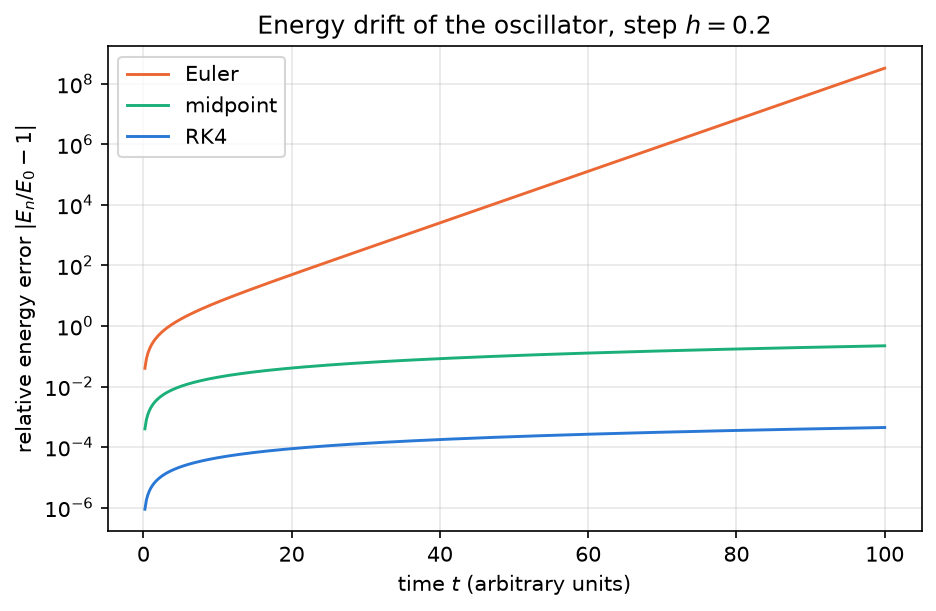

Figure 02a.7 saved as Revision/textbook/figures/02a_7_energy_drift.png
RESULT energy errors at t = 100 (Euler, midpoint, RK4) = 3.286e+08, 2.214e-01, 4.421e-04
PASS after 500 steps: Euler energy off by > 1e8, midpoint by 10-30 %, RK4 < 5e-4


In [13]:
long_runs = {name: np.array(solve(step, oscillator, Y0, 100.0, 500)[1])
             for name, step in METHODS.items()}
fig, ax = plt.subplots()
t_long = np.linspace(0.0, 100.0, 501)
drift = {}
for name in METHODS:
    energy = 0.5 * (long_runs[name][:, 0] ** 2 + long_runs[name][:, 1] ** 2)
    drift[name] = np.abs(energy / 0.5 - 1.0)
    ax.semilogy(t_long[1:], drift[name][1:], color=COLORS[name], lw=1.4,
                label=LABELS[name])
ax.set_xlabel("time $t$ (arbitrary units)")
ax.set_ylabel("relative energy error $|E_n/E_0 - 1|$")
ax.set_title("Energy drift of the oscillator, step $h = 0.2$")
ax.legend()
save_figure(fig, "energy_drift",
            "The relative error of the oscillator energy, $|E_n/E_0 - 1|$, on a "
            "logarithmic vertical axis, against the time $t$ from 0 to 100 "
            "(arbitrary units), for the step $h = 0.2$ (500 steps). Euler: the "
            "energy grows by the factor $1.04$ per step and is $3 \\times 10^{8}$ "
            "times too large at the end. Midpoint: it grows by the factor "
            "$1.0004$ per step (22 percent after 500 steps). RK4: it shrinks by "
            "the fraction $8.8 \\times 10^{-7}$ per step, a relative error below "
            "$5 \\times 10^{-4}$ at the end. The Euler line is straight (the same "
            "factor at every step); the other two curves bend over, because "
            "their small errors grow in proportion to the number of steps.")
report("energy errors at t = 100 (Euler, midpoint, RK4)",
       ", ".join(f"{drift[name][-1]:.3e}" for name in METHODS))
check(drift["euler"][-1] > 1e8 and 0.1 < drift["midpoint"][-1] < 0.3
      and drift["rk4"][-1] < 5e-4,
      "after 500 steps: Euler energy off by > 1e8, midpoint by 10-30 %, RK4 < 5e-4")

## 14. Richardson's rule: an error estimate without the exact answer

In real problems the exact answer is unknown. Suppose a method of order $p$ gives
$Y_h = Y + C h^p$ and $Y_{h/2} = Y + C h^p / 2^p$, where $Y$ is the exact value.
Subtracting the second from the first, $Y_h - Y_{h/2} = C h^p (1 - 2^{-p}) =
(C h^p / 2^p)(2^p - 1)$, so the error of the finer result is

$$Y_{h/2} - Y = \frac{C h^p}{2^p} = \frac{Y_h - Y_{h/2}}{2^p - 1},$$

which for RK4 ($p = 4$) is $(Y_h - Y_{h/2})/15$. Removing this estimated error
gives the *extrapolated* value $Y_{h/2} - (Y_h - Y_{h/2})/15 = (16 Y_{h/2} -
Y_h)/15$. The next cell tests both statements on problem A for $N = 2$ to 128
(finer run $2N$ steps). The rule assumes that the error is already close to
$C h^p$; the test shows from which $N$ on this is true.

N =   2 ->   4: estimated  1.844e-05, actual  1.476e-05, extrapolated error -3.68e-06
N =   4 ->   8: estimated  9.285e-07, actual  8.308e-07, extrapolated error -9.77e-08
N =   8 ->  16: estimated  5.210e-08, actual  4.928e-08, extrapolated error -2.82e-09
N =  16 ->  32: estimated  3.085e-09, actual  3.001e-09, extrapolated error -8.45e-11
N =  32 ->  64: estimated  1.877e-10, actual  1.851e-10, extrapolated error -2.59e-12
N =  64 -> 128: estimated  1.158e-11, actual  1.149e-11, extrapolated error -8.02e-14
N = 128 -> 256: estimated  7.186e-13, actual  7.159e-13, extrapolated error -2.72e-15


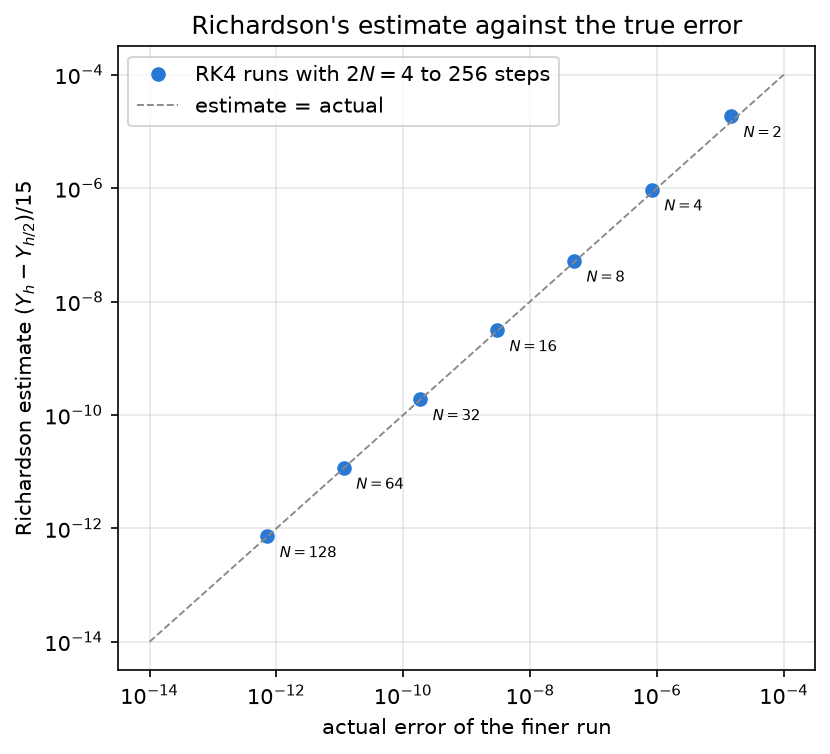

Figure 02a.8 saved as Revision/textbook/figures/02a_8_richardson.png
PASS Richardson's estimate is within 10 % of the actual error for N >= 8
PASS the extrapolated value is more than 10 times more accurate (N = 8 to 64)


In [14]:
N_R = [2 ** k for k in range(1, 8)]  # the coarse runs: 2 ... 128 steps
coarse = np.array([solve(rk4_step, decay, 1.0, 1.0, n)[1][-1] for n in N_R])
fine = np.array([solve(rk4_step, decay, 1.0, 1.0, 2 * n)[1][-1] for n in N_R])
estimated = (coarse - fine) / 15.0  # Richardson's estimate of the error of fine
actual = fine - EXACT_A  # the true error of fine (we know the exact answer here)
extrapolated = (16.0 * fine - coarse) / 15.0
for n, e_est, e_act, e_ext in zip(N_R, estimated, actual, extrapolated - EXACT_A):
    say(f"N = {n:3d} -> {2 * n:3d}: estimated {e_est: .3e}, actual {e_act: .3e}, "
        f"extrapolated error {e_ext: .2e}")
fig, ax = plt.subplots(figsize=(6.0, 5.4))
ax.loglog(np.abs(actual), np.abs(estimated), "o", color=COLORS["rk4"], ms=6,
          label="RK4 runs with $2N = 4$ to $256$ steps")
for n, x_value, y_value in zip(N_R, np.abs(actual), np.abs(estimated)):
    ax.annotate(f"$N = {n}$", (x_value, y_value), textcoords="offset points",
                xytext=(6, -10), fontsize=7)
diagonal = np.array([1e-14, 1e-4])
ax.loglog(diagonal, diagonal, "--", color=COLORS["guide"], lw=0.9,
          label="estimate = actual")
ax.set_xlabel("actual error of the finer run")
ax.set_ylabel("Richardson estimate $(Y_h - Y_{h/2})/15$")
ax.set_title("Richardson's estimate against the true error")
ax.legend(loc="upper left")
save_figure(fig, "richardson",
            "Richardson's error estimate $(Y_h - Y_{h/2})/15$ of RK4 for problem A "
            "at $t = 1$ (vertical axis) against the true error of the finer run "
            "(horizontal axis), both pure numbers on logarithmic axes; each point "
            "is labelled with the number of steps $N$ of the coarse run, the finer "
            "run has $2N$. The points lie on the dashed diagonal: the estimate, "
            "made without knowing the exact answer, is the error itself to within "
            "10 percent once the coarse run has $N \\geq 8$ steps.")
ratio = estimated[2:] / actual[2:]
check(np.all((ratio > 0.9) & (ratio < 1.1)),
      "Richardson's estimate is within 10 % of the actual error for N >= 8")
check(np.all(np.abs(extrapolated[2:6] - EXACT_A) < np.abs(actual[2:6]) / 10),
      "the extrapolated value is more than 10 times more accurate (N = 8 to 64)")

## 15. The last check

The last cell checks that all 8 figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [15]:
names = ["scale_factors", "scale_factor_product", "convergence_loglog",
         "error_ratios", "rounding_floor", "phase_portrait", "energy_drift",
         "richardson"]
present = [output_file(f"{FIGURE_FOLDER}/02a_{k}_{name}.png").is_file()
           for k, name in enumerate(names, 1)]
check(all(present), f"all {len(names)} figure files of notebook 02a exist")
all_checks_passed()

PASS all 8 figure files of notebook 02a exist
ALL 29 CHECKS PASSED (notebook 02a)


## 16. What this notebook showed

- One step of size $h$ multiplies the solution of $y' = \lambda y$ by an
  amplification factor $R(\lambda h)$: $1 + z$ (Euler), $1 + z + z^2/2$
  (midpoint) and $1 + z + z^2/2 + z^3/6 + z^4/24$ (RK4), the first 2, 3 and 5
  terms of the series of $e^{z}$.
- Measured on a log-log plot, the error at a fixed end time is $C h^p$ with the
  orders $p = 1, 2, 4$; halving the step divides the error by 2, 4 and 16.
- RK4 reaches an error of about $10^{-16}$ with a few thousand steps; smaller
  steps make the result worse, because rounding errors add up, though they
  partly cancel and stay far below the pessimistic bound $N \epsilon$.
- The first term of the series of $e^{z}$ that a method misses predicts its
  error: for $y' = -y$ at $t = 1$ the error is $e^{-1}(-1)^p h^p/(p+1)!$. At the
  step $h = 1/300$ of the Revision Kohn-Sham solver (900 RK4 steps on an
  interval of length 3, read from its record) that is about $-6 \times 10^{-4}$
  for Euler, $7 \times 10^{-7}$ for the midpoint method and
  $4 \times 10^{-13}$ for RK4.
- The product of the inflating 3-space factor $e^{x_4}$ and the deflating
  extra-time factor $e^{-x_4}$ is exactly 1; Euler's method destroys this
  compensation (factor $1 - h^2$ per step), RK4 keeps it to $3 \times 10^{-5}$
  even with the coarse step $h = 0.25$ (factor $1 + h^6/72 + h^8/576$).
- For the oscillator the energy factors per step are exactly $1 + h^2$,
  $1 + h^4/4$ and $1 - h^6/72 + h^8/576$; the computed energies follow these
  predictions to 13 digits. The angle of $R(ih)$ predicts how far each method
  runs ahead of the exact solution (midpoint) or lags behind it (Euler, RK4).
- Richardson's rule $(Y_h - Y_{h/2})/(2^p - 1)$ estimates the error of the finer
  run $Y_{h/2}$ without the exact answer, and $(16 Y_{h/2} - Y_h)/15$ is a better
  value than either run.